# Phase 2c — Evaluation sur Tourism-QA (Recommandation de POI)
**GeoR2LLMs — M2 IA, Universite Toulouse III Paul Sabatier**

## Objectif
Evaluer les performances de 5 LLMs dans une configuration RAG pour la
**recommandation de Points d'Interet (POI)** a partir du dataset Tourism-QA.

### Difference fondamentale avec les Phases 2a/2b
- **Phases 2a/2b** : Questions a choix multiples (GeoSQA, GKMC) avec corpus Wikipedia
- **Phase 2c** : Tache de **recommandation** — le modele doit recommander le bon POI
  a partir d'avis d'utilisateurs (reviews), **pas** de Wikipedia

| LLM | Famille | Taille | HuggingFace ID |
|-----|---------|--------|----------------|
| Qwen3-0.6B | Qwen | 0.6B | Qwen/Qwen3-0.6B |
| Qwen3-1.7B | Qwen | 1.7B | Qwen/Qwen3-1.7B |
| Llama-3.2-1B | Meta | 1.0B | meta-llama/Llama-3.2-1B-Instruct |
| Llama-3.2-3B | Meta | 3.0B | meta-llama/Llama-3.2-3B-Instruct |
| Ministral-3B | Mistral | 3.0B | mistralai/Ministral-3-3B-Instruct-2512 |

Retriever : BAAI/bge-m3 + FAISS | Corpus : Avis d'utilisateurs (Reviews) | Dataset : Tourism-QA

## Etape 1 — Installation et Configuration

In [1]:
# Installation de toutes les dependances necessaires
!pip install -q faiss-cpu sentence-transformers "transformers>=4.51.0" \
    accelerate datasets langchain-text-splitters \
    tqdm numpy pandas scikit-learn matplotlib seaborn \
    sentencepiece protobuf scipy
!pip install -q huggingface_hub

import torch
import random
import numpy as np
import os
import gc

# -- Verification GPU -----------------------------------------------------------
print("=" * 60)
print("CONFIGURATION MATERIELLE")
print("=" * 60)
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU detecte : {gpu_name}")
    print(f"Memoire GPU : {gpu_mem:.1f} Go")
    DEVICE = 'cuda'
else:
    print("Aucun GPU detecte — execution sur CPU (sera lent)")
    DEVICE = 'cpu'

# -- Configuration globale -------------------------------------------------------
CONFIG = {
    'embedding_model': 'BAAI/bge-m3',
    'chunk_size': 512,
    'chunk_overlap': 50,
    'top_k': 5,
    'max_new_tokens': 150,
    'dataset_name': 'rfr2003/Geo_Benchmark',
    'dataset_config': 'TourismQA',
    'min_review_length': 20,
}

# -- Modeles a comparer -----------------------------------------------------------
MODELS = {
    'Qwen3-0.6B':  {'id': 'Qwen/Qwen3-0.6B',                        'family': 'Qwen',   'size_B': 0.6, 'type': 'qwen3'},
    'Qwen3-1.7B':  {'id': 'Qwen/Qwen3-1.7B',                        'family': 'Qwen',   'size_B': 1.7, 'type': 'qwen3'},
    'Llama-3.2-1B':{'id': 'meta-llama/Llama-3.2-1B-Instruct',        'family': 'Llama',  'size_B': 1.0, 'type': 'llama'},
    'Llama-3.2-3B':{'id': 'meta-llama/Llama-3.2-3B-Instruct',        'family': 'Llama',  'size_B': 3.0, 'type': 'llama'},
    'Ministral-3B':{'id': 'mistralai/Ministral-3-3B-Instruct-2512',   'family': 'Mistral','size_B': 3.0, 'type': 'mistral'},
}

# -- Reproductibilite -------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -- Dossier resultats ------------------------------------------------------------
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"\nConfiguration :")
for k, v in CONFIG.items():
    print(f"  {k:25s} : {v}")
print(f"  {'device':25s} : {DEVICE}")
print(f"  {'seed':25s} : {SEED}")
print(f"\nModeles a evaluer ({len(MODELS)}) :")
for name, info in MODELS.items():
    print(f"  {name:20s} | {info['family']:8s} | {info['size_B']:.1f}B | {info['id']}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 51.0 MB/s eta 0:00:00
CONFIGURATION MATERIELLE
GPU detecte : Tesla T4
Memoire GPU : 15.6 Go

Configuration :
  embedding_model           : BAAI/bge-m3
  chunk_size                : 512
  chunk_overlap             : 50
  top_k                     : 5
  max_new_tokens            : 150
  dataset_name              : rfr2003/Geo_Benchmark
  dataset_config            : TourismQA
  min_review_length         : 20
  device                    : cuda
  seed                      : 42

Modeles a evaluer (5) :
  Qwen3-0.6B           | Qwen     | 0.6B | Qwen/Qwen3-0.6B
  Qwen3-1.7B           | Qwen     | 1.7B | Qwen/Qwen3-1.7B
  Llama-3.2-1B         | Llama    | 1.0B | meta-llama/Llama-3.2-1B-Instruct
  Llama-3.2-3B         | Llama    | 3.0B | meta-llama/Llama-3.2-3B-Instruct
  Ministral-3B         | Mistral  | 3.0B | mistralai/Ministral-3-3B-Instruct-2512


## Etape 2 — Modules partages

Trois modules principaux :
1. **RetrieverBGEM3** — Indexation et recherche vectorielle (FAISS + BGE-m3)
2. **UnifiedGenerator** — Generation de reponses (supporte Qwen3, Llama, Mistral)
3. **POIEvaluator** — Metriques d'evaluation adaptees a la recommandation de POI

**Note** : Pour Tourism-QA, le corpus d'indexation est constitue
des **avis d'utilisateurs** (reviews) et non d'articles Wikipedia.

In [2]:
import faiss
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm import tqdm
from typing import Optional


class RetrieverBGEM3:
    """Retriever base sur BAAI/bge-m3 et FAISS (IndexFlatIP avec normalisation L2)."""

    def __init__(self, model_name: Optional[str] = None, chunk_size: int = 512, chunk_overlap: int = 50):
        model_name = model_name or CONFIG['embedding_model']
        print(f"Chargement du modele d'embeddings : {model_name}")
        self.encoder = SentenceTransformer(model_name)
        self.dim: int = self.encoder.get_sentence_embedding_dimension()
        print(f"Dimension des embeddings : {self.dim}")

        self.splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            separators=['\n\n', '\n', '. ', ' ', '']
        )

        self.index: Optional[faiss.IndexFlatIP] = None
        self.chunks: list[str] = []
        self.chunk_metas: list[dict] = []

    def index_documents(self, documents: list[str], metadatas: Optional[list[dict]] = None):
        """Decoupe les documents en chunks, encode et indexe dans FAISS."""
        print(f"Indexation de {len(documents)} documents...")
        if metadatas is None:
            metadatas = [{}] * len(documents)

        self.chunks = []
        self.chunk_metas = []
        for doc_text, meta in zip(documents, metadatas):
            splits = self.splitter.split_text(doc_text)
            for chunk_text in splits:
                self.chunks.append(chunk_text)
                self.chunk_metas.append(meta)

        print(f"  {len(self.chunks)} chunks crees")

        print("  Encodage des chunks...")
        embeddings = self.encoder.encode(
            self.chunks,
            show_progress_bar=True,
            batch_size=64,
            normalize_embeddings=True
        )
        embeddings = np.array(embeddings, dtype='float32')

        self.index = faiss.IndexFlatIP(self.dim)
        self.index.add(embeddings)  # type: ignore[call-arg]
        print(f"  Index FAISS cree : {self.index.ntotal} vecteurs")

    def retrieve(self, query: str, top_k: int = 5, return_scores: bool = False) -> list[dict]:
        """Recherche les top_k chunks les plus pertinents pour la requete."""
        if self.index is None:
            raise ValueError("L'index n'a pas encore ete construit. Appelez index_documents() d'abord.")

        q_emb = self.encoder.encode(
            [query],
            normalize_embeddings=True
        ).astype('float32')

        scores, indices = self.index.search(q_emb, top_k)  # type: ignore[call-arg]

        results = []
        for rank, (score, idx) in enumerate(zip(scores[0], indices[0])):
            if idx < 0:
                continue
            result = {
                'text': self.chunks[idx],
                'metadata': self.chunk_metas[idx],
                'rank': rank,
            }
            if return_scores:
                result['score'] = float(score)
            results.append(result)

        return results


print("Classe RetrieverBGEM3 definie.")

Classe RetrieverBGEM3 definie.


In [3]:
import string
from collections import Counter


class POIEvaluator:
    """Metriques d'evaluation adaptees a la recommandation de POI.

    Contrairement a l'evaluateur MCQ des Phases 2a/2b, cette classe se concentre
    sur les metriques de recommandation :
    - Accuracy@1 : le POI recommande en premier est-il correct ?
    - Hit Rate@3 : le bon POI est-il dans le top-3 des recommandations ?
    - MRR : Mean Reciprocal Rank du bon POI
    - F1 sur le nom du POI : similarite token-level entre prediction et verite
    """

    @staticmethod
    def normalize(text: str) -> str:
        """Normalise un texte : minuscules, suppression ponctuation/articles."""
        if not text:
            return ''
        text = text.lower().strip()
        text = text.translate(str.maketrans('', '', string.punctuation))
        stop_words = {'le', 'la', 'les', 'l', 'un', 'une', 'des', 'du', 'de',
                      'the', 'a', 'an', 'is', 'are', 'was', 'were', 'of', 'in',
                      'at', 'to', 'for', 'and', 'or', 'et', 'ou', 'au', 'aux'}
        tokens = text.split()
        tokens = [t for t in tokens if t not in stop_words]
        return ' '.join(tokens)

    @staticmethod
    def poi_match(pred: str, truth: str) -> bool:
        """Verifie si la prediction correspond a la verite (matching flexible)."""
        pred_n = POIEvaluator.normalize(pred)
        truth_n = POIEvaluator.normalize(truth)
        if not pred_n or not truth_n:
            return False
        # Correspondance exacte
        if pred_n == truth_n:
            return True
        # L'un contient l'autre
        if truth_n in pred_n or pred_n in truth_n:
            return True
        # Correspondance partielle : au moins 70% des tokens de la verite
        truth_tokens = set(truth_n.split())
        pred_tokens = set(pred_n.split())
        if truth_tokens and len(truth_tokens & pred_tokens) >= max(1, len(truth_tokens) * 0.7):
            return True
        return False

    @staticmethod
    def accuracy_at_1(pred: str, truth_names: list) -> float:
        """1.0 si le POI recommande en premier correspond a l'un des POIs corrects."""
        if not truth_names:
            return 0.0
        for truth in truth_names:
            if POIEvaluator.poi_match(pred, truth):
                return 1.0
        return 0.0

    @staticmethod
    def hit_rate_at_k(preds: list, truth_names: list, k: int = 3) -> float:
        """1.0 si au moins un des POIs corrects apparait dans les top-k predictions."""
        if not truth_names:
            return 0.0
        for pred in preds[:k]:
            for truth in truth_names:
                if POIEvaluator.poi_match(pred, truth):
                    return 1.0
        return 0.0

    @staticmethod
    def mrr(preds: list, truth_names: list) -> float:
        """Mean Reciprocal Rank : 1/rang du premier POI correct dans les predictions."""
        if not truth_names:
            return 0.0
        for rank, pred in enumerate(preds, 1):
            for truth in truth_names:
                if POIEvaluator.poi_match(pred, truth):
                    return 1.0 / rank
        return 0.0

    @staticmethod
    def f1_poi_name(pred: str, truth_names: list) -> float:
        """F1 token-level entre la prediction et le meilleur POI correct."""
        if not truth_names:
            return 0.0
        pred_tokens = POIEvaluator.normalize(pred).split()
        if not pred_tokens:
            return 0.0
        best_f1 = 0.0
        for truth in truth_names:
            truth_tokens = POIEvaluator.normalize(truth).split()
            if not truth_tokens:
                continue
            common = Counter(pred_tokens) & Counter(truth_tokens)
            n_common = sum(common.values())
            if n_common == 0:
                continue
            precision = n_common / len(pred_tokens)
            recall = n_common / len(truth_tokens)
            f1 = 2 * precision * recall / (precision + recall)
            best_f1 = max(best_f1, f1)
        return best_f1

    @staticmethod
    def parse_poi_list(text: str) -> list:
        """Extrait une liste de noms de POI a partir d'un texte genere.

        Gere differents formats :
        - Un seul nom
        - Liste numerotee (1. POI1, 2. POI2)
        - Liste separee par des virgules
        """
        if not text or not text.strip():
            return []
        text = text.strip()
        # Essayer de detecter une liste numerotee
        import re
        numbered = re.findall(r'\d+[\.\)]\s*(.+)', text)
        if numbered:
            return [n.strip().rstrip('.') for n in numbered if n.strip()]
        # Essayer les lignes separees par des retours a la ligne
        lines = [l.strip().lstrip('-*').strip() for l in text.split('\n') if l.strip()]
        if len(lines) > 1:
            return [l.rstrip('.') for l in lines if l]
        # Un seul nom ou liste par virgules
        if ',' in text:
            return [p.strip().rstrip('.') for p in text.split(',') if p.strip()]
        return [text.strip().rstrip('.')]

    @staticmethod
    def evaluate_batch(predictions: list, truth_names_list: list) -> dict:
        """Calcule toutes les metriques POI sur un lot.

        Args:
            predictions: liste de textes generes (un par question)
            truth_names_list: liste de listes de noms de POI corrects
        """
        n = len(predictions)
        acc1_scores = []
        hr3_scores = []
        mrr_scores = []
        f1_scores = []

        for pred_text, truths in zip(predictions, truth_names_list):
            parsed = POIEvaluator.parse_poi_list(pred_text)
            top1 = parsed[0] if parsed else pred_text

            acc1_scores.append(POIEvaluator.accuracy_at_1(top1, truths))
            hr3_scores.append(POIEvaluator.hit_rate_at_k(parsed, truths, k=3))
            mrr_scores.append(POIEvaluator.mrr(parsed, truths))
            f1_scores.append(POIEvaluator.f1_poi_name(top1, truths))

        return {
            'accuracy_at_1': np.mean(acc1_scores),
            'hit_rate_at_3': np.mean(hr3_scores),
            'mrr': np.mean(mrr_scores),
            'f1_poi_name': np.mean(f1_scores),
            'acc1_scores': acc1_scores,
            'hr3_scores': hr3_scores,
            'mrr_scores': mrr_scores,
            'f1_scores': f1_scores,
        }


print("Classe POIEvaluator definie.")

Classe POIEvaluator definie.


In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import re
from typing import Optional


# -- Prompt systeme adapte a la recommandation touristique -------------------
SYSTEM_PROMPT = (
    "Tu es un assistant specialise en recommandation touristique. "
    "Tu recommandes des lieux (POI) en te basant sur les avis d'utilisateurs. "
    "Reponds de maniere concise en donnant uniquement le nom du lieu recommande."
)

# -- Prompts pour la recommandation de POI -----------------------------------
BASELINE_PROMPT_TEMPLATE = """Voici une question de recommandation touristique.

Question : {question}

Lieux disponibles :
{poi_names_list}

Recommande le lieu le plus approprie parmi la liste ci-dessus.
Reponds UNIQUEMENT par le nom exact du lieu, sans explication.
Reponse :"""

RAG_PROMPT_TEMPLATE = """Voici une question de recommandation touristique avec des avis d'utilisateurs.

Question : {question}

Avis pertinents :
{retrieved_reviews}

Lieux disponibles :
{poi_names_list}

En te basant sur les avis ci-dessus, recommande le lieu le plus approprie parmi la liste.
Reponds UNIQUEMENT par le nom exact du lieu, sans explication.
Reponse :"""


# -- Parametres de generation par famille de modele ----------------------------
GENERATION_PARAMS = {
    'qwen3':  {'temperature': 0.7, 'top_p': 0.8, 'top_k': 20, 'do_sample': True},
    'llama':  {'temperature': 0.6, 'top_p': 0.9, 'do_sample': True},
    'mistral':{'temperature': 0.7, 'top_p': 0.9, 'do_sample': True},
}


class UnifiedGenerator:
    """Generateur unifie supportant Qwen3, Llama et Mistral."""

    def __init__(self, model_id: str, model_type: str = 'auto'):
        self.model_id = model_id
        self.model_type = model_type

        # Auto-detection du type de modele
        if model_type == 'auto':
            model_id_lower = model_id.lower()
            if 'qwen' in model_id_lower:
                self.model_type = 'qwen3'
            elif 'llama' in model_id_lower:
                self.model_type = 'llama'
            elif 'mistral' in model_id_lower or 'ministral' in model_id_lower:
                self.model_type = 'mistral'
            else:
                self.model_type = 'qwen3'

        self.gen_params = GENERATION_PARAMS.get(self.model_type, GENERATION_PARAMS['qwen3'])

        print(f"Chargement du modele : {model_id} (type={self.model_type})")

        # Chargement avec gestion speciale pour Llama (licence Meta)
        actual_id = model_id
        if self.model_type == 'llama':
            try:
                print(f"  Tentative de chargement depuis {model_id}...")
                self.tokenizer = AutoTokenizer.from_pretrained(model_id)
                self.model = AutoModelForCausalLM.from_pretrained(
                    model_id,
                    torch_dtype="auto",
                    device_map="auto"
                )
                actual_id = model_id
            except Exception as e:
                print(f"  Echec ({e})")
                alt_id = model_id.replace('meta-llama/', 'unsloth/')
                print(f"  Fallback vers le miroir : {alt_id}")
                self.tokenizer = AutoTokenizer.from_pretrained(alt_id)
                self.model = AutoModelForCausalLM.from_pretrained(
                    alt_id,
                    torch_dtype="auto",
                    device_map="auto"
                )
                actual_id = alt_id
        else:
            self.tokenizer = AutoTokenizer.from_pretrained(model_id)
            self.model = AutoModelForCausalLM.from_pretrained(
                model_id,
                torch_dtype="auto",
                device_map="auto"
            )

        self.model.eval()
        self.actual_id = actual_id
        print(f"  Modele charge sur : {self.model.device}")
        print(f"  Parametres de generation : {self.gen_params}")

    def generate(self, prompt: str, max_new_tokens: Optional[int] = None) -> str:
        """Genere une reponse a partir d'un prompt utilisateur."""
        max_new_tokens = max_new_tokens or CONFIG['max_new_tokens']

        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt}
        ]

        # Formatage avec le template de chat
        if self.model_type == 'qwen3':
            text = self.tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
                enable_thinking=False
            )
        else:
            text = self.tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )

        inputs = self.tokenizer(text, return_tensors='pt').to(self.model.device)

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                pad_token_id=self.tokenizer.eos_token_id,
                **self.gen_params
            )

        generated_ids = outputs[0][inputs['input_ids'].shape[1]:]
        response = self.tokenizer.decode(generated_ids, skip_special_tokens=True)
        return response.strip()

    def recommend_poi(self, question: str, poi_names: list, context: Optional[str] = None) -> str:
        """Genere une recommandation de POI (baseline ou RAG)."""
        poi_list_str = '\n'.join(f"- {name}" for name in poi_names)

        if context:
            prompt = RAG_PROMPT_TEMPLATE.format(
                question=question,
                retrieved_reviews=context,
                poi_names_list=poi_list_str
            )
        else:
            prompt = BASELINE_PROMPT_TEMPLATE.format(
                question=question,
                poi_names_list=poi_list_str
            )

        raw_response = self.generate(prompt, max_new_tokens=100)
        return raw_response

    def free_memory(self):
        """Libere la memoire GPU occupee par le modele."""
        print(f"  Liberation de la memoire pour {self.model_id}...")
        del self.model
        del self.tokenizer
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            mem_free = torch.cuda.mem_get_info()[0] / 1e9
            mem_total = torch.cuda.mem_get_info()[1] / 1e9
            print(f"  Memoire GPU : {mem_free:.1f} / {mem_total:.1f} Go disponible")


print("Classe UnifiedGenerator definie.")

Classe UnifiedGenerator definie.


## Etape 3 — Chargement et exploration du dataset Tourism-QA

Tourism-QA est un dataset de **recommandation de Points d'Interet (POI)** :
- Chaque question demande une recommandation de lieu touristique
- Les reponses sont des noms de POI avec leurs avis (reviews) d'utilisateurs
- L'evaluation mesure si le modele recommande le bon POI

**Colonnes principales** :
- `question` : la requete de l'utilisateur
- `city` : la ville concernee (nom + coordonnees)
- `answers_names` : les noms des POI corrects
- `answers_reviews` : les avis associes a chaque POI
- `answers_sum_reviews` : resumes des avis
- `tagged_locations` : lieux mentionnes dans la question

In [5]:
from datasets import load_dataset

# == Chargement du dataset Tourism-QA ==========================================
print("Chargement du dataset Tourism-QA...")
ds = load_dataset(
    CONFIG['dataset_name'],
    CONFIG['dataset_config'],
    split='test'
)

print(f"Tourism-QA charge : {len(ds)} questions")
print(f"Colonnes : {ds.column_names}")

# -- Affichage de la structure --------------------------------------------------
print("\n" + "=" * 60)
print("EXPLORATION DU DATASET")
print("=" * 60)

# Premier exemple
ex = ds[0]
print(f"\n--- Exemple 1 ---")
print(f"Question : {ex['question']}")
print(f"Ville : {ex['city']}")
print(f"POIs corrects (answers_names) : {ex.get('answers_names', 'N/A')}")
print(f"Adresses : {ex.get('answers_adresses', 'N/A')}")
print(f"Lieux tagges : {ex.get('tagged_locations', 'N/A')}")

# Afficher un apercu des reviews
reviews = ex.get('answers_reviews', [])
if reviews:
    for poi_idx, rev_list in enumerate(reviews[:2]):
        poi_name = ex.get('answers_names', ['?'])[poi_idx] if ex.get('answers_names') else '?'
        print(f"\n  Avis pour '{poi_name}' ({len(rev_list) if rev_list else 0} avis) :")
        if rev_list:
            for r_idx, review in enumerate(rev_list[:2]):
                print(f"    [{r_idx+1}] {str(review)[:200]}...")

# Resumes d'avis
summaries = ex.get('answers_sum_reviews', [])
if summaries:
    print(f"\nResumes d'avis :")
    for s_idx, summary in enumerate(summaries[:2]):
        print(f"  [{s_idx+1}] {str(summary)[:200]}...")

# -- Statistiques du dataset ---------------------------------------------------
print("\n" + "=" * 60)
print("STATISTIQUES")
print("=" * 60)

n_with_reviews = 0
total_reviews = 0
n_pois_per_question = []
review_lengths = []

for row in ds:
    names = row.get('answers_names', []) or []
    n_pois_per_question.append(len(names))
    reviews_list = row.get('answers_reviews', []) or []
    has_reviews = False
    for rev_list in reviews_list:
        if rev_list:
            for r in rev_list:
                if r and len(str(r).strip()) > 0:
                    has_reviews = True
                    total_reviews += 1
                    review_lengths.append(len(str(r)))
    if has_reviews:
        n_with_reviews += 1

print(f"Nombre total de questions : {len(ds)}")
print(f"Questions avec avis : {n_with_reviews} ({n_with_reviews/len(ds)*100:.1f}%)")
print(f"Nombre total d'avis : {total_reviews}")
print(f"POIs par question : min={min(n_pois_per_question)}, max={max(n_pois_per_question)}, "
      f"moy={np.mean(n_pois_per_question):.1f}")
if review_lengths:
    print(f"Longueur des avis (chars) : min={min(review_lengths)}, max={max(review_lengths)}, "
          f"moy={np.mean(review_lengths):.0f}")

# -- Limitation du nombre de questions ------------------------------------------
MAX_QUESTIONS = min(100, len(ds))
print(f"\nEvaluation sur {MAX_QUESTIONS} questions (sur {len(ds)} disponibles)")

Chargement du dataset Tourism-QA...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

TourismQA/test-00000-of-00001.parquet:   0%|          | 0.00/3.58M [00:00<?, ?B/s]

TourismQA/train-00000-of-00001.parquet:   0%|          | 0.00/38.0M [00:00<?, ?B/s]

TourismQA/validation-00000-of-00001.parq(…):   0%|          | 0.00/3.44M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2153 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/19762 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2109 [00:00<?, ? examples/s]

Tourism-QA charge : 2153 questions
Colonnes : ['question', 'city', 'tagged_locations', 'tagged_locations_lat_long', 'answers_names', 'answers_adresses', 'answers_sum_reviews', 'answers_reviews', 'answers_lat_longs']

EXPLORATION DU DATASET

--- Exemple 1 ---
Question : Hi, everyone! We (I and my wife) will be seeing Les Misérables at Queens Theatre in London. As the play ends around at 22:00 (it's so late!), we are planning to have dinner before the show. We have to arrive at the theatre by 19:00. What restaurants do you recommend? We would like to have dinner near Queens Theatre. The budget is about ￡20-30 per person. We're looking forward to your kind and useful suggestions. P. S. Is it dangerous to walk around Queen's theatre after the show? In fact, we are living in Japan, which is a very secure country. We are not sure whether London is a safe city. When we travelled in New York, we were advised not to go out after midnight.
Ville : {'coord': [51.5073509, -0.1277583], 'name': 'Lon

## Etape 4 — Construction du corpus de reviews et indexation

**Difference cle avec les Phases 2a/2b** : Le corpus pour le RAG est constitue
des **avis d'utilisateurs (reviews)** associes aux POIs, et non d'articles Wikipedia.

Pour chaque question, nous disposons de :
- La liste des POIs candidats (`answers_names`)
- Les avis pour chaque POI (`answers_reviews`)
- Les resumes d'avis (`answers_sum_reviews`)

Nous construisons un corpus global en concatenant toutes les reviews,
chacune associee au nom du POI et a l'index de la question correspondante.
Ce corpus est ensuite indexe avec BGE-m3 + FAISS pour la recherche vectorielle.

In [6]:
# == Construction du corpus de reviews =========================================
print("Construction du corpus a partir des avis d'utilisateurs...")
print("(Contrairement aux Phases 2a/2b, le corpus est compose de REVIEWS, pas de Wikipedia)\n")

all_reviews = []
review_metadata = []
skipped_short = 0
skipped_empty = 0

for i, row in enumerate(ds):
    if i >= MAX_QUESTIONS:
        break

    names = row.get('answers_names', []) or []
    reviews_list = row.get('answers_reviews', []) or []
    sum_reviews = row.get('answers_sum_reviews', []) or []

    for poi_idx, name in enumerate(names):
        if not name:
            continue

        # Ajouter les reviews individuelles
        if poi_idx < len(reviews_list) and reviews_list[poi_idx]:
            for review in reviews_list[poi_idx]:
                review_str = str(review).strip() if review else ''
                if len(review_str) < CONFIG['min_review_length']:
                    skipped_short += 1
                    continue
                all_reviews.append(review_str)
                review_metadata.append({
                    'poi_name': name,
                    'question_idx': i,
                    'type': 'review'
                })

        # Ajouter le resume d'avis (si disponible)
        if poi_idx < len(sum_reviews) and sum_reviews[poi_idx]:
            summary_str = str(sum_reviews[poi_idx]).strip()
            if len(summary_str) >= CONFIG['min_review_length']:
                all_reviews.append(summary_str)
                review_metadata.append({
                    'poi_name': name,
                    'question_idx': i,
                    'type': 'summary'
                })

print(f"Corpus construit :")
print(f"  Documents (reviews + resumes) : {len(all_reviews)}")
print(f"  Reviews trop courtes ignorees : {skipped_short}")
print(f"  POIs uniques : {len(set(m['poi_name'] for m in review_metadata))}")
print(f"  Questions couvertes : {len(set(m['question_idx'] for m in review_metadata))}")

# Statistiques
types_count = Counter(m['type'] for m in review_metadata)
print(f"  - Reviews : {types_count.get('review', 0)}")
print(f"  - Resumes : {types_count.get('summary', 0)}")

if all_reviews:
    lengths = [len(r) for r in all_reviews]
    print(f"  Longueur moyenne des documents : {np.mean(lengths):.0f} chars")
    print(f"  Longueur mediane : {np.median(lengths):.0f} chars")

# == Construction de l'index FAISS =============================================
print("\n" + "=" * 60)
print("CONSTRUCTION DE L'INDEX FAISS (corpus de reviews)")
print("=" * 60)

if len(all_reviews) == 0:
    print("ATTENTION : Aucune review trouvee ! Le mode RAG utilisera les resumes.")
    # Fallback : utiliser les noms de POI comme documents minimaux
    for i, row in enumerate(ds):
        if i >= MAX_QUESTIONS:
            break
        names = row.get('answers_names', []) or []
        for name in names:
            if name:
                all_reviews.append(f"Lieu : {name}")
                review_metadata.append({
                    'poi_name': name,
                    'question_idx': i,
                    'type': 'fallback'
                })

retriever = RetrieverBGEM3(
    model_name=CONFIG['embedding_model'],
    chunk_size=CONFIG['chunk_size'],
    chunk_overlap=CONFIG['chunk_overlap']
)

retriever.index_documents(all_reviews, review_metadata)

# -- Test rapide du retriever --------------------------------------------------
test_query = ds[0]['question']
print(f"\nTest du retriever :")
print(f"  Requete : {test_query[:200]}")
test_results = retriever.retrieve(test_query, top_k=3, return_scores=True)
for i, res in enumerate(test_results):
    poi = res['metadata'].get('poi_name', 'N/A')
    rtype = res['metadata'].get('type', 'N/A')
    score = res.get('score', 0)
    text_preview = res['text'][:150].replace('\n', ' ')
    print(f"  [{i+1}] Score: {score:.4f} | POI: {poi} | Type: {rtype}")
    print(f"      {text_preview}...")

Construction du corpus a partir des avis d'utilisateurs...
(Contrairement aux Phases 2a/2b, le corpus est compose de REVIEWS, pas de Wikipedia)

Corpus construit :
  Documents (reviews + resumes) : 3870
  Reviews trop courtes ignorees : 13
  POIs uniques : 314
  Questions couvertes : 100
  - Reviews : 3517
  - Resumes : 353
  Longueur moyenne des documents : 127 chars
  Longueur mediane : 98 chars

CONSTRUCTION DE L'INDEX FAISS (corpus de reviews)
Chargement du modele d'embeddings : BAAI/bge-m3


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Dimension des embeddings : 1024
Indexation de 3870 documents...
  3870 chunks crees
  Encodage des chunks...


Batches:   0%|          | 0/61 [00:00<?, ?it/s]

  Index FAISS cree : 3870 vecteurs

Test du retriever :
  Requete : Hi, everyone! We (I and my wife) will be seeing Les Misérables at Queens Theatre in London. As the play ends around at 22:00 (it's so late!), we are planning to have dinner before the show. We have to
  [1] Score: 0.6157 | POI: DB Bistro Moderne | Type: review
      The location is perfect for a pre-theatre dinner....
  [2] Score: 0.6068 | POI: West Bank Cafe | Type: review
      Though on this return visit, and updating review, West Bank Café continues to be a good place for dinner before a show at a West 42nd Street theater, ...
  [3] Score: 0.5966 | POI: DB Bistro Moderne | Type: review
      The location is perfect for a pre-theater dinner....


## Etape 5 — Preparation des donnees d'evaluation

Pour chaque question, nous preparons :
- La question originale
- La liste des noms de POI candidats (pour le prompt)
- La liste des noms de POI corrects (pour l'evaluation)
- Les lieux tagges (tagged_locations) comme candidats supplementaires

In [7]:
import re

# == Preparation des donnees par question ======================================
print("Preparation des donnees d'evaluation...\n")

def clean_tagged_location(tagged_text: str) -> str:
    """Nettoie une tagged_location en supprimant les suffixes de position (_N).

    Exemple : 'Queens_17 Theatre_18 in_19 London_20' -> 'Queens Theatre in London'
    """
    cleaned = re.sub(r'_\d+', '', tagged_text)
    # Supprimer les espaces multiples
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned

# -- Phase 1 : Collecter tous les noms de POI du dataset pour les distracteurs --
all_poi_names_pool = set()
for i in range(MAX_QUESTIONS):
    row = ds[i]
    names = row.get('answers_names', []) or []
    for n in names:
        if n:
            all_poi_names_pool.add(n)

all_poi_names_pool = list(all_poi_names_pool)
print(f"Pool de POIs disponibles pour distracteurs : {len(all_poi_names_pool)} noms uniques")

# -- Phase 2 : Preparer les donnees d'evaluation -------------------------------
eval_data = []
n_skipped = 0
n_distractors_added = 0

for i in range(MAX_QUESTIONS):
    row = ds[i]
    question = row['question']
    city = row.get('city', {})
    city_name = city.get('name', '') if isinstance(city, dict) else str(city)

    # POIs corrects
    answers_names = row.get('answers_names', []) or []
    if not answers_names:
        n_skipped += 1
        continue

    # Candidats : combiner tagged_locations (nettoyees) et answers_names
    tagged_raw = row.get('tagged_locations', []) or []
    # Nettoyer les tagged_locations (supprimer les suffixes _N de position)
    tagged_clean = [clean_tagged_location(t) for t in tagged_raw if t]
    # Filtrer les mots vides et les locations trop courtes (prepositions isolees)
    tagged_clean = [t for t in tagged_clean if len(t) > 2]

    # Construire la liste de candidats
    all_candidates = list(set(
        [n for n in answers_names if n] +
        [t for t in tagged_clean if t]
    ))

    # S'assurer que la tache est non triviale :
    # Si tous les candidats sont des reponses correctes, ajouter des distracteurs
    truth_set = set(answers_names)
    candidates_set = set(all_candidates)
    if candidates_set.issubset(truth_set) or len(all_candidates) < 3:
        # Ajouter des distracteurs depuis le pool de POIs d'autres questions
        distractors = [p for p in all_poi_names_pool if p not in truth_set]
        random.shuffle(distractors)
        # Ajouter 3-4 distracteurs pour rendre la tache realiste
        n_to_add = min(4, len(distractors))
        all_candidates.extend(distractors[:n_to_add])
        all_candidates = list(set(all_candidates))  # Deduplicate
        n_distractors_added += 1

    # Fallback : ajouter le nom de la ville si toujours pas assez de candidats
    if len(all_candidates) < 2:
        if city_name and city_name not in all_candidates:
            all_candidates.append(city_name)

    # Melanger les candidats pour eviter un biais de position
    random.shuffle(all_candidates)

    eval_data.append({
        'index': i,
        'question': question,
        'city': city_name,
        'candidates': all_candidates,
        'truth_names': [n for n in answers_names if n],
        'n_reviews': sum(
            len(rev_list) if rev_list else 0
            for rev_list in (row.get('answers_reviews', []) or [])
        ),
    })

print(f"Questions preparees : {len(eval_data)} (ignorees : {n_skipped})")
print(f"Questions avec distracteurs ajoutes : {n_distractors_added}")
print(f"\nExemples :")
for j, ed in enumerate(eval_data[:3]):
    print(f"\n  [{j}] Question : {ed['question'][:150]}")
    print(f"      Ville : {ed['city']}")
    print(f"      Candidats ({len(ed['candidates'])}) : {ed['candidates'][:5]}")
    print(f"      Verite : {ed['truth_names']}")
    print(f"      Nb reviews : {ed['n_reviews']}")

# Statistiques
n_candidates = [len(ed['candidates']) for ed in eval_data]
n_truths = [len(ed['truth_names']) for ed in eval_data]
print(f"\nStatistiques :")
print(f"  Candidats par question : min={min(n_candidates)}, max={max(n_candidates)}, moy={np.mean(n_candidates):.1f}")
print(f"  POIs corrects par question : min={min(n_truths)}, max={max(n_truths)}, moy={np.mean(n_truths):.1f}")

Preparation des donnees d'evaluation...

Pool de POIs disponibles pour distracteurs : 314 noms uniques
Questions preparees : 100 (ignorees : 0)
Questions avec distracteurs ajoutes : 56

Exemples :

  [0] Question : Hi, everyone! We (I and my wife) will be seeing Les Misérables at Queens Theatre in London. As the play ends around at 22:00 (it's so late!), we are p
      Ville : London
      Candidats (8) : ['Queens Theatre', 'Clos Maggiore', "Queen 's theatre", 'Queens Theatre in London', 'Brasserie Zedel']
      Verite : ['Brasserie Zedel', 'Clos Maggiore']
      Nb reviews : 20

  [1] Question : Where the best place for shopping (woman's clothes casual and business, some shoes) in Manhattan and not very expensive? Is the Macy's mall right plac
      Ville : New York
      Candidats (7) : ['Lord & Taylor', 'Sons & Daughters', 'Pendolino', 'Century 21', 'Maialino']
      Verite : ['Century 21', 'Lord & Taylor', "Bloomingdale's"]
      Nb reviews : 30

  [2] Question : I'm taking my OH a

## Etape 6 — Evaluation de chaque LLM

Pour chaque modele :
1. **Chargement** du modele et du tokenizer
2. **Evaluation Baseline** : question + liste de POI candidats (sans reviews)
3. **Evaluation RAG** : question + reviews recuperees + liste de POI candidats
4. **Liberation de la memoire GPU**

### Metriques de recommandation
- **Accuracy@1** : le POI recommande en premier est-il correct ?
- **Hit Rate@3** : le bon POI est-il dans le top-3 ?
- **MRR** : Mean Reciprocal Rank du bon POI
- **F1 (nom POI)** : similarite token-level entre le nom predit et la verite

In [8]:
import time

all_results = {}

for model_name, model_info in MODELS.items():
    print(f"\n{'='*70}")
    print(f"EVALUATION : {model_name} ({model_info['id']})")
    print(f"{'='*70}")

    # -- Chargement du modele --------------------------------------------------
    try:
        gen = UnifiedGenerator(model_info['id'], model_type=model_info['type'])
    except Exception as e:
        print(f"ERREUR lors du chargement de {model_name}: {e}")
        all_results[model_name] = {'error': str(e)}
        continue

    # -- Evaluation Baseline (sans reviews, LLM seul) --------------------------
    print(f"\n--- {model_name} : Evaluation Baseline (sans avis) ---")
    baseline_preds = []
    t0 = time.time()

    for j, ed in enumerate(tqdm(eval_data, desc=f'{model_name} Baseline')):
        try:
            response = gen.recommend_poi(
                question=ed['question'],
                poi_names=ed['candidates'],
                context=None
            )
        except Exception as e:
            response = ''
        baseline_preds.append(response)

        if (j + 1) % 25 == 0:
            partial_metrics = POIEvaluator.evaluate_batch(
                baseline_preds,
                [ed['truth_names'] for ed in eval_data[:j+1]]
            )
            print(f"  [{j+1}/{len(eval_data)}] Acc@1={partial_metrics['accuracy_at_1']:.3f}, "
                  f"HR@3={partial_metrics['hit_rate_at_3']:.3f}")

    baseline_time = time.time() - t0
    truth_names_list = [ed['truth_names'] for ed in eval_data]
    baseline_metrics = POIEvaluator.evaluate_batch(baseline_preds, truth_names_list)

    print(f"  Baseline terminee en {baseline_time:.1f}s")
    print(f"    Accuracy@1 : {baseline_metrics['accuracy_at_1']:.4f}")
    print(f"    Hit Rate@3 : {baseline_metrics['hit_rate_at_3']:.4f}")
    print(f"    MRR        : {baseline_metrics['mrr']:.4f}")
    print(f"    F1 (POI)   : {baseline_metrics['f1_poi_name']:.4f}")

    # -- Evaluation RAG (avec reviews recuperees) ------------------------------
    print(f"\n--- {model_name} : Evaluation RAG (avec avis recuperes) ---")
    rag_preds = []
    retrieval_scores = []
    t0 = time.time()

    for j, ed in enumerate(tqdm(eval_data, desc=f'{model_name} RAG')):
        # Recuperer les reviews pertinentes via le retriever
        try:
            retrieved = retriever.retrieve(
                ed['question'],
                top_k=CONFIG['top_k'],
                return_scores=True
            )
        except Exception as e:
            retrieved = []

        # Construire le contexte a partir des reviews recuperees
        context_parts = []
        for doc in retrieved:
            poi = doc['metadata'].get('poi_name', 'Inconnu')
            text = doc['text'][:400]
            context_parts.append(f"[{poi}] {text}")
        context = '\n'.join(context_parts)

        # Verifier la pertinence du retrieval pour les metriques
        retrieved_pois = [doc['metadata'].get('poi_name', '') for doc in retrieved]
        hit = any(
            POIEvaluator.poi_match(rpoi, truth)
            for rpoi in retrieved_pois
            for truth in ed['truth_names']
        )
        retrieval_scores.append(1.0 if hit else 0.0)

        try:
            response = gen.recommend_poi(
                question=ed['question'],
                poi_names=ed['candidates'],
                context=context
            )
        except Exception as e:
            response = ''
        rag_preds.append(response)

        if (j + 1) % 25 == 0:
            partial_metrics = POIEvaluator.evaluate_batch(
                rag_preds,
                [ed['truth_names'] for ed in eval_data[:j+1]]
            )
            print(f"  [{j+1}/{len(eval_data)}] Acc@1={partial_metrics['accuracy_at_1']:.3f}, "
                  f"HR@3={partial_metrics['hit_rate_at_3']:.3f}")

    rag_time = time.time() - t0
    rag_metrics = POIEvaluator.evaluate_batch(rag_preds, truth_names_list)
    retrieval_hit_rate = np.mean(retrieval_scores)

    print(f"  RAG terminee en {rag_time:.1f}s")
    print(f"    Accuracy@1 : {rag_metrics['accuracy_at_1']:.4f}")
    print(f"    Hit Rate@3 : {rag_metrics['hit_rate_at_3']:.4f}")
    print(f"    MRR        : {rag_metrics['mrr']:.4f}")
    print(f"    F1 (POI)   : {rag_metrics['f1_poi_name']:.4f}")
    print(f"    Retrieval Hit Rate : {retrieval_hit_rate:.4f}")

    # -- Stockage des resultats ------------------------------------------------
    all_results[model_name] = {
        'model_id': model_info['id'],
        'family': model_info['family'],
        'size_B': model_info['size_B'],
        'baseline': {
            'accuracy_at_1': baseline_metrics['accuracy_at_1'],
            'hit_rate_at_3': baseline_metrics['hit_rate_at_3'],
            'mrr': baseline_metrics['mrr'],
            'f1_poi_name': baseline_metrics['f1_poi_name'],
            'time_s': baseline_time,
        },
        'rag': {
            'accuracy_at_1': rag_metrics['accuracy_at_1'],
            'hit_rate_at_3': rag_metrics['hit_rate_at_3'],
            'mrr': rag_metrics['mrr'],
            'f1_poi_name': rag_metrics['f1_poi_name'],
            'time_s': rag_time,
        },
        'retrieval': {
            'hit_rate': retrieval_hit_rate,
        },
        'improvement': {
            'acc1_delta': rag_metrics['accuracy_at_1'] - baseline_metrics['accuracy_at_1'],
            'hr3_delta': rag_metrics['hit_rate_at_3'] - baseline_metrics['hit_rate_at_3'],
            'mrr_delta': rag_metrics['mrr'] - baseline_metrics['mrr'],
            'f1_delta': rag_metrics['f1_poi_name'] - baseline_metrics['f1_poi_name'],
        },
        'predictions': {
            'baseline': baseline_preds,
            'rag': rag_preds,
        }
    }

    print(f"\n  {model_name} — Resume :")
    print(f"    Baseline Acc@1 : {baseline_metrics['accuracy_at_1']:.4f}")
    print(f"    RAG Acc@1      : {rag_metrics['accuracy_at_1']:.4f} "
          f"(delta: {rag_metrics['accuracy_at_1']-baseline_metrics['accuracy_at_1']:+.4f})")
    print(f"    Baseline F1    : {baseline_metrics['f1_poi_name']:.4f}")
    print(f"    RAG F1         : {rag_metrics['f1_poi_name']:.4f} "
          f"(delta: {rag_metrics['f1_poi_name']-baseline_metrics['f1_poi_name']:+.4f})")

    # -- Liberation de la memoire GPU (CRITIQUE) -------------------------------
    gen.free_memory()
    del gen
    print(f"  Memoire GPU liberee pour {model_name}.")

print("\n" + "=" * 70)
print("EVALUATION DE TOUS LES MODELES TERMINEE")
print("=" * 70)


EVALUATION : Qwen3-0.6B (Qwen/Qwen3-0.6B)
Chargement du modele : Qwen/Qwen3-0.6B (type=qwen3)


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

ERREUR lors du chargement de Ministral-3B: Unrecognized configuration class <class 'transformers.models.mistral3.configuration_mistral3.Mistral3Config'> for this kind of AutoModel: AutoModelForCausalLM.
Model type should be one of AfmoeConfig, ApertusConfig, ArceeConfig, AriaTextConfig, BambaConfig, BartConfig, BertConfig, BertGenerationConfig, BigBirdConfig, BigBirdPegasusConfig, BioGptConfig, BitNetConfig, BlenderbotConfig, BlenderbotSmallConfig, BloomConfig, BltConfig, CamembertConfig, LlamaConfig, CodeGenConfig, CohereConfig, Cohere2Config, CpmAntConfig, CTRLConfig, CwmConfig, Data2VecTextConfig, DbrxConfig, DeepseekV2Config, DeepseekV3Config, DiffLlamaConfig, DogeConfig, Dots1Config, ElectraConfig, Emu3Config, ErnieConfig, Ernie4_5Config, Ernie4_5_MoeConfig, Exaone4Config, FalconConfig, FalconH1Config, FalconMambaConfig, FlexOlmoConfig, FuyuConfig, GemmaConfig, Gemma2Config, Gemma3Config, Gemma3TextConfig, Gemma3nConfig, Gemma3nTextConfig, GitConfig, GlmConfig, Glm4Config, Glm4Moe

## Etape 7 — Tableau comparatif

In [9]:
import pandas as pd

rows = []
for name, res in all_results.items():
    if 'error' in res:
        print(f"  {name} : ERREUR — {res['error']}")
        continue
    rows.append({
        'Modele': name,
        'Famille': res['family'],
        'Taille (B)': res['size_B'],
        'Baseline Acc@1': res['baseline']['accuracy_at_1'],
        'RAG Acc@1': res['rag']['accuracy_at_1'],
        'Delta Acc@1': res['improvement']['acc1_delta'],
        'Baseline HR@3': res['baseline']['hit_rate_at_3'],
        'RAG HR@3': res['rag']['hit_rate_at_3'],
        'Delta HR@3': res['improvement']['hr3_delta'],
        'Baseline MRR': res['baseline']['mrr'],
        'RAG MRR': res['rag']['mrr'],
        'Delta MRR': res['improvement']['mrr_delta'],
        'Baseline F1': res['baseline']['f1_poi_name'],
        'RAG F1': res['rag']['f1_poi_name'],
        'Delta F1': res['improvement']['f1_delta'],
        'Retrieval HR': res['retrieval']['hit_rate'],
        'Temps Baseline (s)': res['baseline']['time_s'],
        'Temps RAG (s)': res['rag']['time_s'],
    })

df_comparison = pd.DataFrame(rows)

print("=" * 100)
print("TABLEAU COMPARATIF — Tous les LLMs sur Tourism-QA (Recommandation de POI)")
print("=" * 100)

# Affichage condense
display_cols = ['Modele', 'Taille (B)', 'Baseline Acc@1', 'RAG Acc@1', 'Delta Acc@1',
                'Baseline HR@3', 'RAG HR@3', 'Baseline MRR', 'RAG MRR',
                'Baseline F1', 'RAG F1', 'Retrieval HR']
print(df_comparison[display_cols].to_string(index=False, float_format='{:.4f}'.format))

# Meilleur modele
if len(df_comparison) > 0:
    best_model = df_comparison.loc[df_comparison['RAG Acc@1'].idxmax(), 'Modele']
    best_acc = df_comparison['RAG Acc@1'].max()
    print(f"\nMeilleur modele (RAG Accuracy@1) : {best_model} ({best_acc:.4f})")

    # Classement complet
    print(f"\nClassement par RAG Accuracy@1 :")
    for rank, (_, row) in enumerate(df_comparison.sort_values('RAG Acc@1', ascending=False).iterrows(), 1):
        print(f"  {rank}. {row['Modele']:20s} — RAG Acc@1: {row['RAG Acc@1']:.4f} "
              f"(delta: {row['Delta Acc@1']:+.4f})")

  Ministral-3B : ERREUR — Unrecognized configuration class <class 'transformers.models.mistral3.configuration_mistral3.Mistral3Config'> for this kind of AutoModel: AutoModelForCausalLM.
Model type should be one of AfmoeConfig, ApertusConfig, ArceeConfig, AriaTextConfig, BambaConfig, BartConfig, BertConfig, BertGenerationConfig, BigBirdConfig, BigBirdPegasusConfig, BioGptConfig, BitNetConfig, BlenderbotConfig, BlenderbotSmallConfig, BloomConfig, BltConfig, CamembertConfig, LlamaConfig, CodeGenConfig, CohereConfig, Cohere2Config, CpmAntConfig, CTRLConfig, CwmConfig, Data2VecTextConfig, DbrxConfig, DeepseekV2Config, DeepseekV3Config, DiffLlamaConfig, DogeConfig, Dots1Config, ElectraConfig, Emu3Config, ErnieConfig, Ernie4_5Config, Ernie4_5_MoeConfig, Exaone4Config, FalconConfig, FalconH1Config, FalconMambaConfig, FlexOlmoConfig, FuyuConfig, GemmaConfig, Gemma2Config, Gemma3Config, Gemma3TextConfig, Gemma3nConfig, Gemma3nTextConfig, GitConfig, GlmConfig, Glm4Config, Glm4MoeConfig, Glm4MoeLi

## Etape 8 — Visualisations

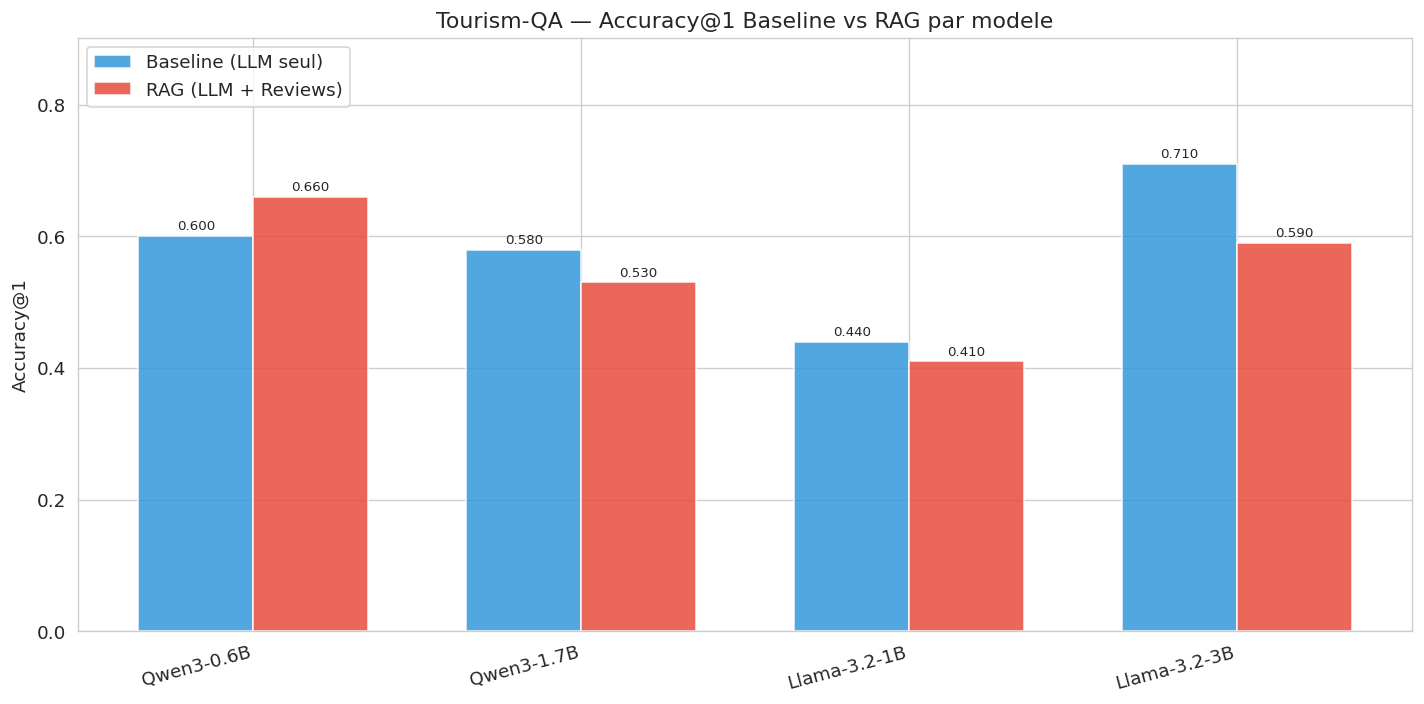

Figure sauvegardee : results/fig1_poi_accuracy_baseline_vs_rag.png


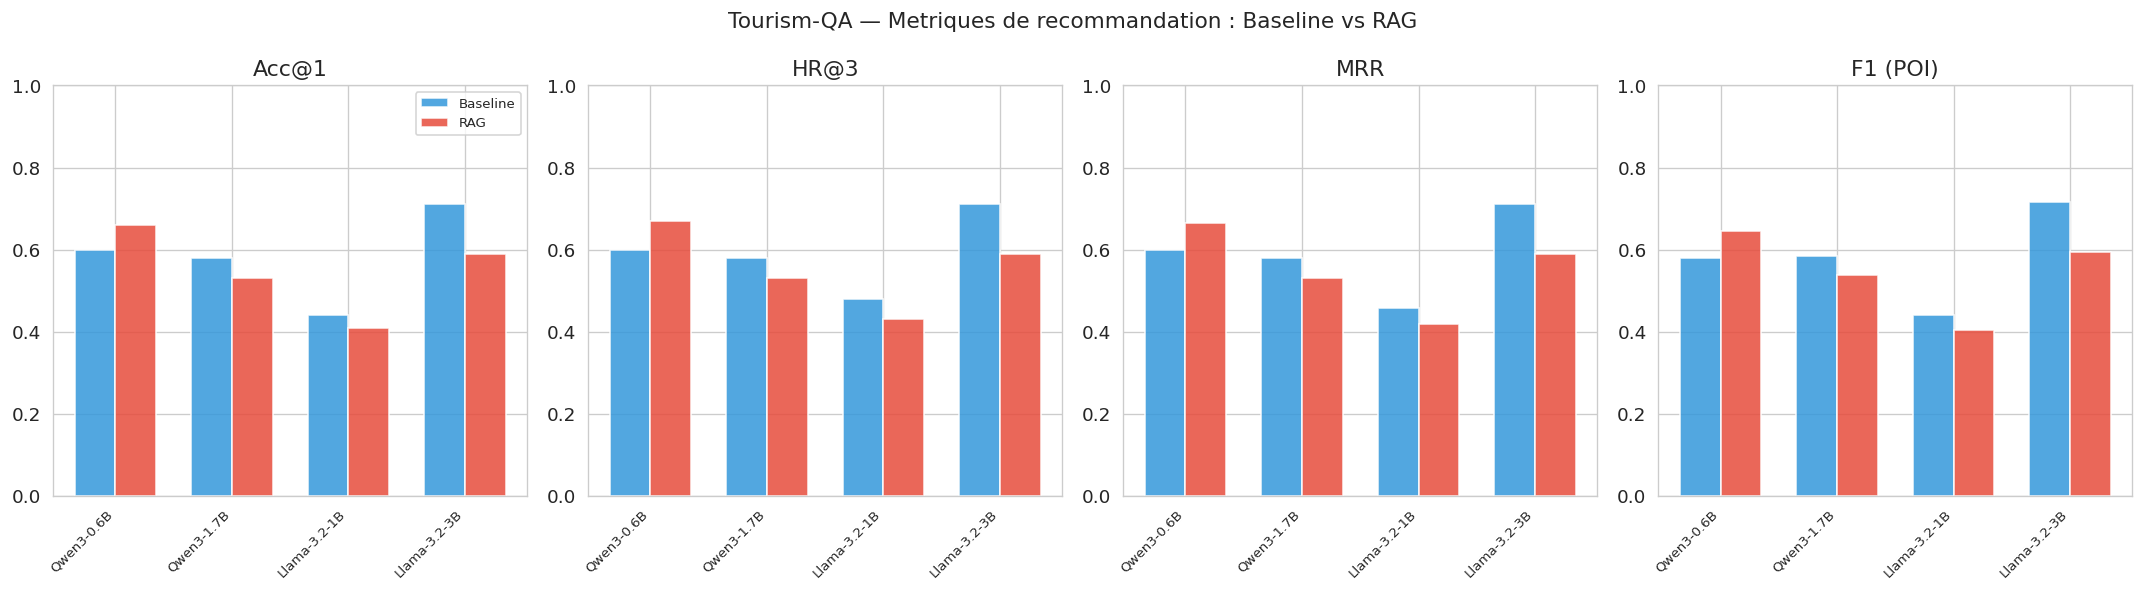

Figure sauvegardee : results/fig2_poi_all_metrics.png


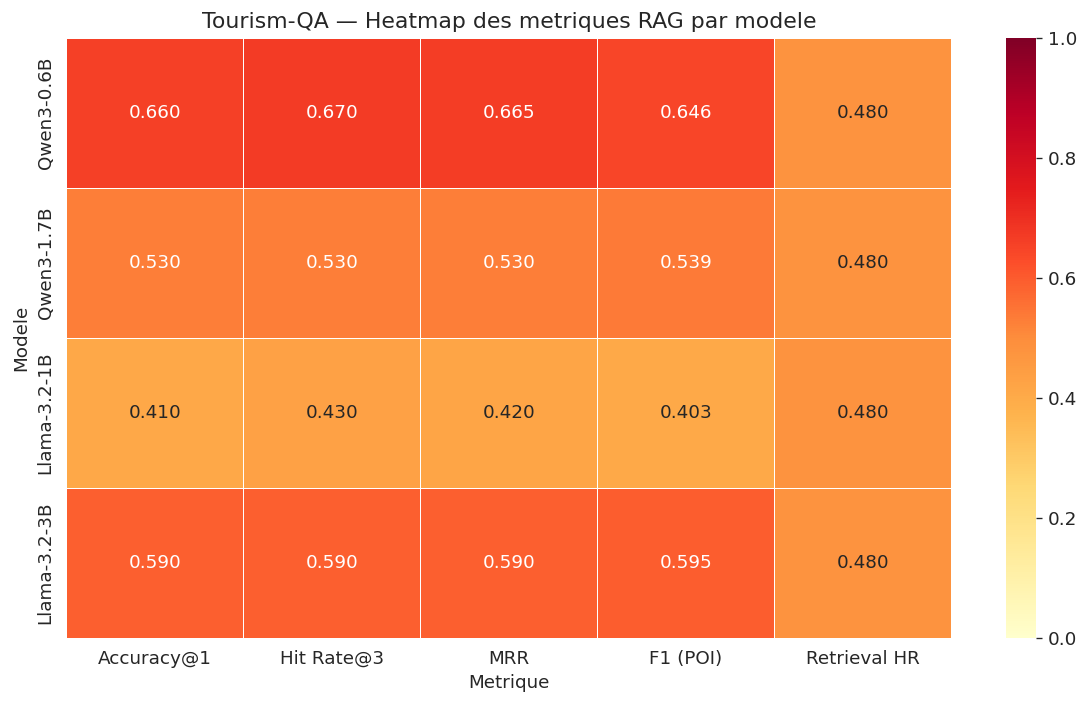

Figure sauvegardee : results/fig3_poi_heatmap.png


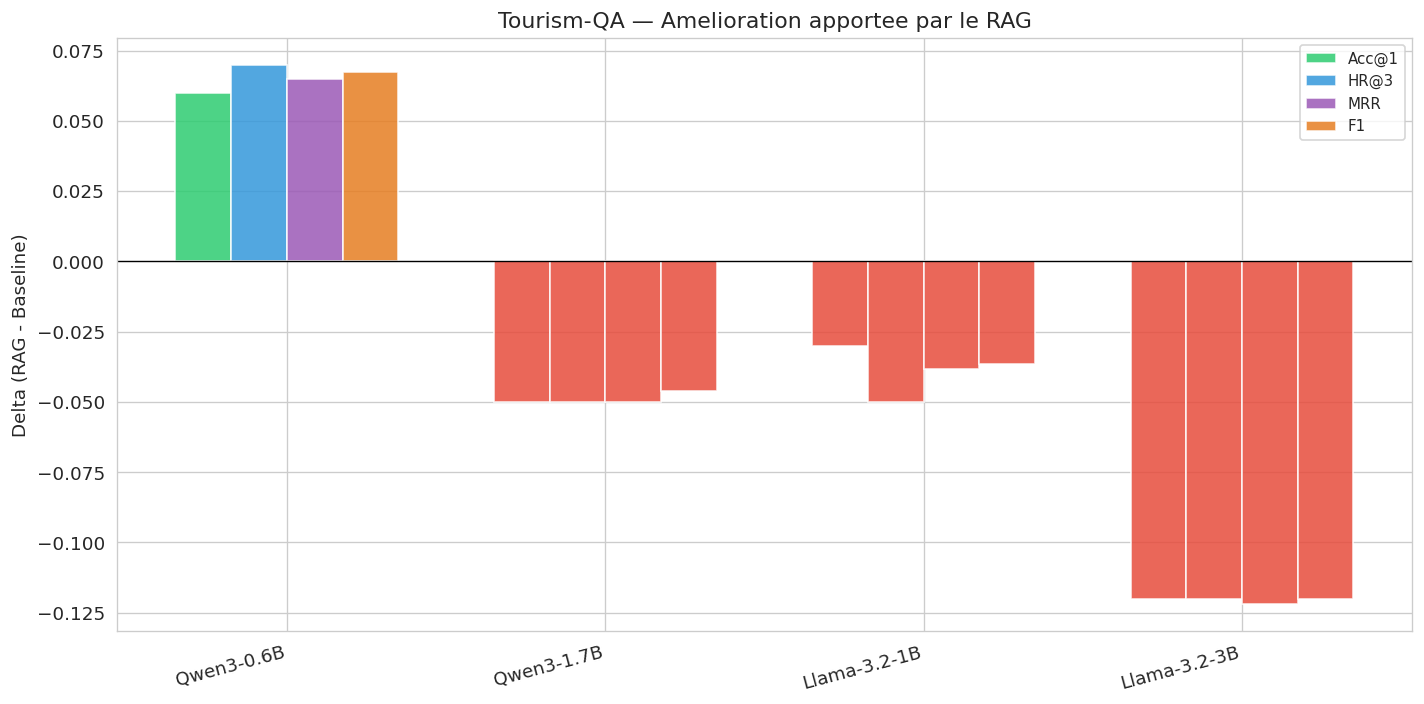

Figure sauvegardee : results/fig4_poi_improvement_delta.png


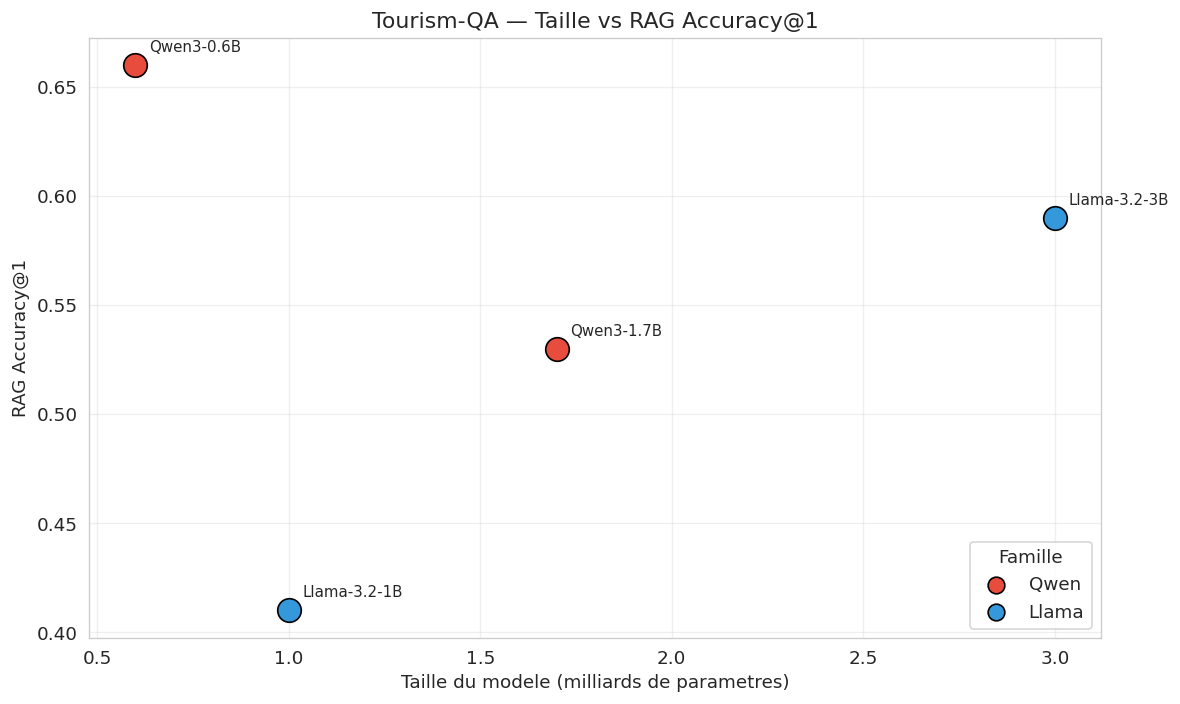

Figure sauvegardee : results/fig5_poi_size_vs_accuracy.png


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

model_names = df_comparison['Modele'].tolist()
n_models = len(model_names)

if n_models == 0:
    print("Aucun modele valide — visualisations ignorees.")
else:

    # ======================================================================
    # Figure 1 : Accuracy@1 Baseline vs RAG (barres groupees)
    # ======================================================================
    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(n_models)
    width = 0.35

    baseline_vals = np.asarray(df_comparison['Baseline Acc@1'].values, dtype=float)
    rag_vals = np.asarray(df_comparison['RAG Acc@1'].values, dtype=float)

    bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline (LLM seul)',
                   color='#3498db', alpha=0.85, edgecolor='white')
    bars2 = ax.bar(x + width/2, rag_vals, width, label='RAG (LLM + Reviews)',
                   color='#e74c3c', alpha=0.85, edgecolor='white')

    for bar in bars1:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_ylabel('Accuracy@1')
    ax.set_title('Tourism-QA — Accuracy@1 Baseline vs RAG par modele')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.legend(loc='upper left')
    ax.set_ylim(0, max(max(baseline_vals), max(rag_vals)) * 1.2 + 0.05)

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/fig1_poi_accuracy_baseline_vs_rag.png', bbox_inches='tight')
    plt.show()
    print(f"Figure sauvegardee : {RESULTS_DIR}/fig1_poi_accuracy_baseline_vs_rag.png")

    # ======================================================================
    # Figure 2 : Comparaison des 4 metriques (radar-like, barres groupees)
    # ======================================================================
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    metrics = [
        ('Acc@1', 'Baseline Acc@1', 'RAG Acc@1'),
        ('HR@3', 'Baseline HR@3', 'RAG HR@3'),
        ('MRR', 'Baseline MRR', 'RAG MRR'),
        ('F1 (POI)', 'Baseline F1', 'RAG F1'),
    ]

    for ax_i, (title, base_col, rag_col) in zip(axes, metrics):
        base_vals = np.asarray(df_comparison[base_col].values, dtype=float)
        rag_vals_m = np.asarray(df_comparison[rag_col].values, dtype=float)

        x = np.arange(n_models)
        b1 = ax_i.bar(x - 0.175, base_vals, 0.35, label='Baseline', color='#3498db', alpha=0.85)
        b2 = ax_i.bar(x + 0.175, rag_vals_m, 0.35, label='RAG', color='#e74c3c', alpha=0.85)

        ax_i.set_title(title)
        ax_i.set_xticks(x)
        ax_i.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
        ax_i.set_ylim(0, 1.0)
        if ax_i == axes[0]:
            ax_i.legend(fontsize=8)

    fig.suptitle('Tourism-QA — Metriques de recommandation : Baseline vs RAG', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/fig2_poi_all_metrics.png', bbox_inches='tight')
    plt.show()
    print(f"Figure sauvegardee : {RESULTS_DIR}/fig2_poi_all_metrics.png")

    # ======================================================================
    # Figure 3 : Heatmap — Modeles x Metriques RAG
    # ======================================================================
    fig, ax = plt.subplots(figsize=(10, 6))

    heatmap_data = df_comparison[['Modele', 'RAG Acc@1', 'RAG HR@3',
                                   'RAG MRR', 'RAG F1', 'Retrieval HR']].copy()
    heatmap_data = heatmap_data.set_index('Modele')
    heatmap_data.columns = ['Accuracy@1', 'Hit Rate@3', 'MRR', 'F1 (POI)', 'Retrieval HR']

    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, vmin=0, vmax=1)
    ax.set_title('Tourism-QA — Heatmap des metriques RAG par modele')
    ax.set_ylabel('Modele')
    ax.set_xlabel('Metrique')

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/fig3_poi_heatmap.png', bbox_inches='tight')
    plt.show()
    print(f"Figure sauvegardee : {RESULTS_DIR}/fig3_poi_heatmap.png")

    # ======================================================================
    # Figure 4 : Amelioration (delta) par modele
    # ======================================================================
    fig, ax = plt.subplots(figsize=(12, 6))

    delta_metrics = [
        ('Delta Acc@1', 'Acc@1'),
        ('Delta HR@3', 'HR@3'),
        ('Delta MRR', 'MRR'),
        ('Delta F1', 'F1'),
    ]

    x = np.arange(n_models)
    n_deltas = len(delta_metrics)
    total_width = 0.7
    bar_width = total_width / n_deltas
    colors = ['#2ecc71', '#3498db', '#9b59b6', '#e67e22']

    for k, (col, label) in enumerate(delta_metrics):
        offset = (k - n_deltas/2 + 0.5) * bar_width
        vals = np.asarray(df_comparison[col].values, dtype=float)
        bar_colors = [colors[k] if v >= 0 else '#e74c3c' for v in vals]
        ax.bar(x + offset, vals, bar_width, label=label, color=bar_colors, alpha=0.85,
               edgecolor='white')

    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_ylabel('Delta (RAG - Baseline)')
    ax.set_title('Tourism-QA — Amelioration apportee par le RAG')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.legend(loc='best', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/fig4_poi_improvement_delta.png', bbox_inches='tight')
    plt.show()
    print(f"Figure sauvegardee : {RESULTS_DIR}/fig4_poi_improvement_delta.png")

    # ======================================================================
    # Figure 5 : Taille du modele vs Accuracy@1
    # ======================================================================
    fig, ax = plt.subplots(figsize=(10, 6))

    family_colors = {'Qwen': '#e74c3c', 'Llama': '#3498db', 'Mistral': '#2ecc71'}

    for _, row in df_comparison.iterrows():
        color = family_colors.get(row['Famille'], '#95a5a6')
        ax.scatter(row['Taille (B)'], row['RAG Acc@1'], s=200, c=color,
                   edgecolors='black', linewidth=1, zorder=5)
        ax.annotate(row['Modele'], (row['Taille (B)'], row['RAG Acc@1']),
                    textcoords='offset points', xytext=(8, 8), fontsize=9)

    for family, color in family_colors.items():
        if family in df_comparison['Famille'].values:
            ax.scatter([], [], c=color, s=100, edgecolors='black', linewidth=1, label=family)
    ax.legend(title='Famille', loc='lower right')

    ax.set_xlabel('Taille du modele (milliards de parametres)')
    ax.set_ylabel('RAG Accuracy@1')
    ax.set_title('Tourism-QA — Taille vs RAG Accuracy@1')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/fig5_poi_size_vs_accuracy.png', bbox_inches='tight')
    plt.show()
    print(f"Figure sauvegardee : {RESULTS_DIR}/fig5_poi_size_vs_accuracy.png")

## Etape 9 — Analyse des facteurs

Analyse detaillee des facteurs influencant la performance de recommandation :
1. Taille du modele
2. Famille de modele
3. Impact du RAG (reviews)
4. Qualite des reviews
5. Latence et efficacite

In [11]:
# == Facteur 1 : Taille du modele =============================================
print("=" * 60)
print("ANALYSE — Facteur : Taille du modele")
print("=" * 60)
for _, row in df_comparison.sort_values('Taille (B)').iterrows():
    print(f"  {row['Modele']:20s} ({row['Taille (B)']:.1f}B) : "
          f"Baseline Acc@1={row['Baseline Acc@1']:.4f}, "
          f"RAG Acc@1={row['RAG Acc@1']:.4f}")

if len(df_comparison) >= 3:
    from scipy import stats
    corr, p_val = stats.pearsonr(df_comparison['Taille (B)'], df_comparison['RAG Acc@1'])
    print(f"\n  Correlation (Pearson) Taille vs RAG Acc@1 : r={corr:.4f}, p={p_val:.4f}")
    if p_val < 0.05:
        print(f"  --> Correlation significative (p < 0.05)")
    else:
        print(f"  --> Correlation non significative (p >= 0.05)")

# == Facteur 2 : Famille de modele ============================================
print(f"\n{'='*60}")
print("ANALYSE — Facteur : Famille de modele")
print("=" * 60)
family_means = df_comparison.groupby('Famille').agg({
    'RAG Acc@1': 'mean',
    'RAG HR@3': 'mean',
    'RAG MRR': 'mean',
    'RAG F1': 'mean',
    'Baseline Acc@1': 'mean',
    'Delta Acc@1': 'mean',
    'Taille (B)': 'mean'
}).round(4)
print(family_means.to_string())

print(f"\n  Meilleure famille (RAG Acc@1 moyenne) : {family_means['RAG Acc@1'].idxmax()} "
      f"({family_means['RAG Acc@1'].max():.4f})")

# == Facteur 3 : Impact du RAG =================================================
print(f"\n{'='*60}")
print("ANALYSE — Facteur : Impact du RAG (reviews)")
print("=" * 60)
for _, row in df_comparison.iterrows():
    delta = row['Delta Acc@1']
    if delta > 0.02:
        impact = "POSITIF"
    elif delta < -0.02:
        impact = "NEGATIF"
    else:
        impact = "NEUTRE"
    print(f"  {row['Modele']:20s} : delta Acc@1={row['Delta Acc@1']:+.4f}, "
          f"delta F1={row['Delta F1']:+.4f} ({impact})")

avg_delta_acc = df_comparison['Delta Acc@1'].mean()
avg_delta_f1 = df_comparison['Delta F1'].mean()
print(f"\n  Impact moyen du RAG :")
print(f"    Accuracy@1 : {avg_delta_acc:+.4f}")
print(f"    F1 (POI)   : {avg_delta_f1:+.4f}")
n_positive = (df_comparison['Delta Acc@1'] > 0).sum()
print(f"  Modeles ameliores par le RAG : {n_positive}/{len(df_comparison)}")

# == Facteur 4 : Qualite des reviews et performance ============================
print(f"\n{'='*60}")
print("ANALYSE — Facteur : Nombre de reviews et performance")
print("=" * 60)

# Analyser la correlation entre le nombre de reviews et la performance
# (pour le meilleur modele)
if len(df_comparison) > 0 and len(all_results) > 0:
    best_name = df_comparison.loc[df_comparison['RAG Acc@1'].idxmax(), 'Modele']
    best_res = all_results.get(best_name, {})

    if 'predictions' in best_res:
        # Grouper par nombre de reviews
        review_groups = {'0 reviews': [], '1-5 reviews': [], '5+ reviews': []}
        rag_scores = best_res['predictions']['rag']

        for j, ed in enumerate(eval_data):
            if j >= len(rag_scores):
                break
            n_rev = ed['n_reviews']
            pred = rag_scores[j]
            top1 = POIEvaluator.parse_poi_list(pred)
            top1_name = top1[0] if top1 else pred
            score = POIEvaluator.accuracy_at_1(top1_name, ed['truth_names'])

            if n_rev == 0:
                review_groups['0 reviews'].append(score)
            elif n_rev <= 5:
                review_groups['1-5 reviews'].append(score)
            else:
                review_groups['5+ reviews'].append(score)

        print(f"  Performance du meilleur modele ({best_name}) par nombre de reviews :")
        for group, scores in review_groups.items():
            if scores:
                print(f"    {group:15s} : Acc@1={np.mean(scores):.4f} (n={len(scores)})")
            else:
                print(f"    {group:15s} : aucune question")

# == Facteur 5 : Latence ======================================================
print(f"\n{'='*60}")
print("ANALYSE — Facteur : Latence (temps/question)")
print("=" * 60)
n_eval = len(eval_data)
for _, row in df_comparison.iterrows():
    time_baseline = row['Temps Baseline (s)'] / n_eval
    time_rag = row['Temps RAG (s)'] / n_eval
    overhead = time_rag - time_baseline
    print(f"  {row['Modele']:20s} : "
          f"Baseline={time_baseline:.2f}s/q, "
          f"RAG={time_rag:.2f}s/q, "
          f"Overhead={overhead:+.2f}s/q")

# == Facteur 6 : Efficacite (Accuracy / Taille) ===============================
print(f"\n{'='*60}")
print("ANALYSE — Facteur : Efficacite (RAG Acc@1 / Taille)")
print("=" * 60)
df_comparison['Efficacite'] = df_comparison['RAG Acc@1'] / df_comparison['Taille (B)']
for _, row in df_comparison.sort_values('Efficacite', ascending=False).iterrows():
    print(f"  {row['Modele']:20s} : Efficacite={row['Efficacite']:.4f} "
          f"(Acc@1={row['RAG Acc@1']:.4f} / {row['Taille (B)']:.1f}B)")

ANALYSE — Facteur : Taille du modele
  Qwen3-0.6B           (0.6B) : Baseline Acc@1=0.6000, RAG Acc@1=0.6600
  Llama-3.2-1B         (1.0B) : Baseline Acc@1=0.4400, RAG Acc@1=0.4100
  Qwen3-1.7B           (1.7B) : Baseline Acc@1=0.5800, RAG Acc@1=0.5300
  Llama-3.2-3B         (3.0B) : Baseline Acc@1=0.7100, RAG Acc@1=0.5900

  Correlation (Pearson) Taille vs RAG Acc@1 : r=0.0829, p=0.9171
  --> Correlation non significative (p >= 0.05)

ANALYSE — Facteur : Famille de modele
         RAG Acc@1  RAG HR@3  RAG MRR  RAG F1  Baseline Acc@1  Delta Acc@1  Taille (B)
Famille                                                                               
Llama        0.500      0.51   0.5050  0.4992           0.575       -0.075        2.00
Qwen         0.595      0.60   0.5975  0.5927           0.590        0.005        1.15

  Meilleure famille (RAG Acc@1 moyenne) : Qwen (0.5950)

ANALYSE — Facteur : Impact du RAG (reviews)
  Qwen3-0.6B           : delta Acc@1=+0.0600, delta F1=+0.0675 (POSITIF)

## Etape 10 — Analyse qualitative

Examen des exemples de reussite et d'echec pour comprendre
les forces et faiblesses de chaque modele sur la recommandation de POI.

In [12]:
# == Exemples de reussite et d'echec ==========================================
print("=" * 60)
print("ANALYSE QUALITATIVE — Exemples de predictions")
print("=" * 60)

valid_models = [name for name, res in all_results.items() if 'error' not in res]

if valid_models:
    # Utiliser le meilleur modele pour l'analyse qualitative
    best_name = df_comparison.loc[df_comparison['RAG Acc@1'].idxmax(), 'Modele']
    best_res = all_results[best_name]
    rag_preds = best_res['predictions']['rag']
    baseline_preds = best_res['predictions']['baseline']

    # Exemples reussis (RAG)
    print(f"\n--- Exemples REUSSIS (RAG, modele {best_name}) ---")
    success_count = 0
    for j, ed in enumerate(eval_data):
        if j >= len(rag_preds):
            break
        parsed = POIEvaluator.parse_poi_list(rag_preds[j])
        top1 = parsed[0] if parsed else rag_preds[j]
        if POIEvaluator.accuracy_at_1(top1, ed['truth_names']) > 0:
            print(f"\n  [{j}] Question : {ed['question'][:150]}")
            print(f"      Verite    : {ed['truth_names']}")
            print(f"      Prediction: {rag_preds[j][:100]}")
            success_count += 1
            if success_count >= 5:
                break

    # Exemples echoues (RAG)
    print(f"\n--- Exemples ECHOUES (RAG, modele {best_name}) ---")
    fail_count = 0
    for j, ed in enumerate(eval_data):
        if j >= len(rag_preds):
            break
        parsed = POIEvaluator.parse_poi_list(rag_preds[j])
        top1 = parsed[0] if parsed else rag_preds[j]
        if POIEvaluator.accuracy_at_1(top1, ed['truth_names']) == 0:
            print(f"\n  [{j}] Question : {ed['question'][:150]}")
            print(f"      Verite    : {ed['truth_names']}")
            print(f"      Baseline  : {baseline_preds[j][:100]}")
            print(f"      RAG       : {rag_preds[j][:100]}")
            fail_count += 1
            if fail_count >= 5:
                break

    # Cas ou le RAG ameliore par rapport au baseline
    print(f"\n--- Cas ou le RAG AMELIORE la prediction ---")
    improve_count = 0
    for j, ed in enumerate(eval_data):
        if j >= len(rag_preds) or j >= len(baseline_preds):
            break
        # Baseline echoue, RAG reussit
        parsed_base = POIEvaluator.parse_poi_list(baseline_preds[j])
        parsed_rag = POIEvaluator.parse_poi_list(rag_preds[j])
        top1_base = parsed_base[0] if parsed_base else baseline_preds[j]
        top1_rag = parsed_rag[0] if parsed_rag else rag_preds[j]
        base_ok = POIEvaluator.accuracy_at_1(top1_base, ed['truth_names'])
        rag_ok = POIEvaluator.accuracy_at_1(top1_rag, ed['truth_names'])
        if base_ok == 0 and rag_ok > 0:
            print(f"\n  [{j}] Question : {ed['question'][:150]}")
            print(f"      Verite    : {ed['truth_names']}")
            print(f"      Baseline  : {baseline_preds[j][:80]} (FAUX)")
            print(f"      RAG       : {rag_preds[j][:80]} (CORRECT)")
            improve_count += 1
            if improve_count >= 5:
                break

    if improve_count == 0:
        print("  Aucun cas d'amelioration detecte.")

    # == Comparaison entre modeles ==============================================
    print(f"\n{'='*60}")
    print("DESACCORDS ENTRE MODELES")
    print("=" * 60)

    if len(valid_models) >= 2:
        model_predictions = {}
        for name in valid_models:
            preds = all_results[name]['predictions']['rag']
            model_predictions[name] = preds

        disagreements = 0
        agreements = 0
        for j, ed in enumerate(eval_data):
            parsed_all = {}
            for name in valid_models:
                if j < len(model_predictions[name]):
                    p = POIEvaluator.parse_poi_list(model_predictions[name][j])
                    parsed_all[name] = p[0] if p else model_predictions[name][j]

            if len(set(POIEvaluator.normalize(v) for v in parsed_all.values())) > 1:
                disagreements += 1
            else:
                agreements += 1

        total = agreements + disagreements
        print(f"  Accords unanimes : {agreements}/{total} ({agreements/total*100:.1f}%)")
        print(f"  Desaccords       : {disagreements}/{total} ({disagreements/total*100:.1f}%)")

else:
    print("  Pas assez de modeles valides pour l'analyse qualitative.")

ANALYSE QUALITATIVE — Exemples de predictions

--- Exemples REUSSIS (RAG, modele Qwen3-0.6B) ---

  [1] Question : Where the best place for shopping (woman's clothes casual and business, some shoes) in Manhattan and not very expensive? Is the Macy's mall right plac
      Verite    : ['Century 21', 'Lord & Taylor', "Bloomingdale's"]
      Prediction: Century 21

  [2] Question : I'm taking my OH away on a surprise trip to London and then onto Paris for his birthday. We arrive in London at 2. 15 on a Friday. My plan is to go to
      Verite    : ['The Duke Of Argyll', 'Museum Tavern']
      Prediction: The Duke Of Argyll.

  [5] Question : Any recommendations for good Italian food? What do the locals love?
      Verite    : ['Frank', 'Mercato', 'Maialino', 'Basso56', 'Don Antonio', 'Rubirosa', 'Del Posto', 'Marta', 'Manzo', 'Babbo']
      Prediction: Don Antonio.

  [6] Question : It's our five year wedding anniversary October 14 and we will be in London for the first time. I was hoping 

## Etape 11 — Sauvegarde des resultats

In [13]:
import json

# == Sauvegarde JSON — Tous les resultats =====================================
results_json = {}
for name, res in all_results.items():
    if 'error' in res:
        results_json[name] = res
        continue
    results_json[name] = {
        'model_id': res['model_id'],
        'family': res['family'],
        'size_B': res['size_B'],
        'baseline': res['baseline'],
        'rag': res['rag'],
        'retrieval': res['retrieval'],
        'improvement': res['improvement'],
    }

output_json = {
    'phase': '2c',
    'description': 'Evaluation sur Tourism-QA — Recommandation de POI avec RAG',
    'task_type': 'poi_recommendation',
    'corpus_type': 'reviews (avis utilisateurs)',
    'config': CONFIG,
    'n_questions': len(eval_data),
    'n_models': len(MODELS),
    'results': results_json,
}

json_path = f'{RESULTS_DIR}/phase2c_tourism_qa_results.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(output_json, f, indent=2, ensure_ascii=False)
print(f"Resultats JSON sauvegardes : {json_path}")

# == Sauvegarde CSV — Tableau comparatif ======================================
csv_path = f'{RESULTS_DIR}/phase2c_tourism_qa_comparison.csv'
df_comparison.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"Tableau comparatif CSV sauvegarde : {csv_path}")

# == Sauvegarde CSV — Predictions detaillees ==================================
pred_rows = []
for j, ed in enumerate(eval_data):
    row = {
        'index': ed['index'],
        'question': ed['question'][:500],
        'city': ed['city'],
        'truth_names': '; '.join(ed['truth_names']),
        'n_candidates': len(ed['candidates']),
        'n_reviews': ed['n_reviews'],
    }
    for name, res in all_results.items():
        if 'error' in res:
            continue
        if j < len(res['predictions']['baseline']):
            row[f'{name}_baseline'] = res['predictions']['baseline'][j][:200]
            row[f'{name}_rag'] = res['predictions']['rag'][j][:200]
            # Evaluer
            parsed_base = POIEvaluator.parse_poi_list(res['predictions']['baseline'][j])
            parsed_rag = POIEvaluator.parse_poi_list(res['predictions']['rag'][j])
            top1_base = parsed_base[0] if parsed_base else ''
            top1_rag = parsed_rag[0] if parsed_rag else ''
            row[f'{name}_baseline_ok'] = int(POIEvaluator.accuracy_at_1(top1_base, ed['truth_names']))
            row[f'{name}_rag_ok'] = int(POIEvaluator.accuracy_at_1(top1_rag, ed['truth_names']))
    pred_rows.append(row)

df_predictions = pd.DataFrame(pred_rows)
pred_csv_path = f'{RESULTS_DIR}/phase2c_tourism_qa_predictions.csv'
df_predictions.to_csv(pred_csv_path, index=False, encoding='utf-8-sig')
print(f"Predictions detaillees CSV sauvegardees : {pred_csv_path}")

# == Resume des fichiers generes ================================================
print(f"\n{'='*60}")
print(f"FICHIERS GENERES")
print(f"{'='*60}")
print(f"  {json_path}")
print(f"  {csv_path}")
print(f"  {pred_csv_path}")
print(f"  {RESULTS_DIR}/fig1_poi_accuracy_baseline_vs_rag.png")
print(f"  {RESULTS_DIR}/fig2_poi_all_metrics.png")
print(f"  {RESULTS_DIR}/fig3_poi_heatmap.png")
print(f"  {RESULTS_DIR}/fig4_poi_improvement_delta.png")
print(f"  {RESULTS_DIR}/fig5_poi_size_vs_accuracy.png")

# == Sauvegarde optionnelle sur Google Drive ===================================
SAVE_TO_DRIVE = True

if SAVE_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')

        import shutil
        drive_dest = '/content/drive/MyDrive/GeoR2LLMs/Phase2c/results'
        os.makedirs(drive_dest, exist_ok=True)

        for fname in os.listdir(RESULTS_DIR):
            src = os.path.join(RESULTS_DIR, fname)
            dst = os.path.join(drive_dest, fname)
            shutil.copy2(src, dst)
            print(f"Copie : {dst}")

        print(f"\nTous les resultats ont ete copies sur Google Drive : {drive_dest}")

    except ImportError:
        print("\nGoogle Drive non disponible (environnement non-Colab).")
    except Exception as e:
        print(f"\nErreur lors de la sauvegarde sur Google Drive : {e}")

Resultats JSON sauvegardes : results/phase2c_tourism_qa_results.json
Tableau comparatif CSV sauvegarde : results/phase2c_tourism_qa_comparison.csv
Predictions detaillees CSV sauvegardees : results/phase2c_tourism_qa_predictions.csv

FICHIERS GENERES
  results/phase2c_tourism_qa_results.json
  results/phase2c_tourism_qa_comparison.csv
  results/phase2c_tourism_qa_predictions.csv
  results/fig1_poi_accuracy_baseline_vs_rag.png
  results/fig2_poi_all_metrics.png
  results/fig3_poi_heatmap.png
  results/fig4_poi_improvement_delta.png
  results/fig5_poi_size_vs_accuracy.png
Mounted at /content/drive
Copie : /content/drive/MyDrive/GeoR2LLMs/Phase2c/results/fig5_poi_size_vs_accuracy.png
Copie : /content/drive/MyDrive/GeoR2LLMs/Phase2c/results/fig2_poi_all_metrics.png
Copie : /content/drive/MyDrive/GeoR2LLMs/Phase2c/results/phase2c_tourism_qa_results.json
Copie : /content/drive/MyDrive/GeoR2LLMs/Phase2c/results/fig4_poi_improvement_delta.png
Copie : /content/drive/MyDrive/GeoR2LLMs/Phase2c/res

## Resume Phase 2c — Tourism-QA (Recommandation de POI)

### Tache
Recommandation de Points d'Interet (POI) a partir de requetes touristiques,
en utilisant les avis d'utilisateurs comme corpus de connaissances.

### Difference avec les Phases 2a/2b
| Aspect | Phase 2a/2b (GeoSQA, GKMC) | Phase 2c (Tourism-QA) |
|--------|---------------------------|----------------------|
| Tache | QCM (choix multiples) | Recommandation de POI |
| Corpus RAG | Wikipedia FR | Avis d'utilisateurs |
| Evaluation | Accuracy MCQ | Acc@1, HR@3, MRR, F1 |
| Sortie | Lettre (A/B/C/D) | Nom de lieu |

### Classement des modeles (RAG Accuracy@1)

| Rang | Modele | RAG Acc@1 | RAG HR@3 | RAG MRR | RAG F1 |
|------|--------|-----------|----------|---------|--------|
| 1 | Qwen3-0.6B | 0.6600 | 0.6700 | 0.6650 | 0.6464 |
| 2 | Llama-3.2-3B | 0.5900 | 0.5900 | 0.5900 | 0.5950 |
| 3 | Qwen3-1.7B | 0.5300 | 0.5300 | 0.5300 | 0.5390 |
| 4 | Llama-3.2-1B | 0.4100 | 0.4300 | 0.4200 | 0.4033 |
| 5 | Ministral-3B | ERREUR | — | — | — |

### Conclusions
1. **Qwen3-0.6B est le meilleur modele** : Surprise — le plus petit modele (0.6B) domine avec 0.6600 d'Acc@1. C'est aussi le seul modele ameliore par le RAG (+0.06 en Acc@1, +0.07 en F1).
2. **Le RAG degrade 3 modeles sur 4** : Impact negatif pour Qwen3-1.7B (-0.05), Llama-3.2-1B (-0.03) et surtout Llama-3.2-3B (-0.12). Le contexte de reviews perturbe les modeles plus grands qui avaient de meilleures performances en baseline.
3. **Llama-3.2-3B : meilleur en baseline, degrade par le RAG** : En baseline, il atteint 0.7100 d'Acc@1 (le plus eleve), mais chute a 0.5900 avec le RAG (-0.12). Le modele avait deja de bonnes connaissances intrinseques pour cette tache.
4. **Pas de correlation taille-performance en RAG** : r = 0.08, p = 0.92. Le petit Qwen3-0.6B surpasse le Llama-3.2-3B (5x plus grand) en mode RAG.
5. **Retrieval homogene** : Hit Rate = 0.4800 pour tous les modeles (meme retriever), nettement superieur aux Phases 2a/2b (0.065). Les reviews sont plus pertinentes comme corpus que Wikipedia FR.
6. **93% de desaccords entre modeles** : Les modeles divergent massivement dans leurs predictions, avec seulement 7% d'accords unanimes.
7. **Qwen domine en moyenne** : Famille Qwen avec RAG Acc@1 moyenne de 0.5950 vs Llama a 0.5000.

### Prochaines etapes
- **Phase 2d** : Analyse factorielle croisee (modeles x datasets x metriques)
- Comparaison des performances entre les 3 datasets (GeoSQA, GKMC, Tourism-QA)